In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_inputs = pd.read_csv('train_inputs.csv')
train_targets = pd.read_csv('train_targets.csv')['RainTomorrow']
val_inputs = pd.read_csv('val_inputs.csv')
val_targets = pd.read_csv('val_targets.csv')['RainTomorrow']
test_inputs = pd.read_csv('test_inputs.csv')
test_targets = pd.read_csv('test_targets.csv')['RainTomorrow']

We have already done the encoding, inputing and pre-processing in the log_regression file

In [4]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(train_inputs, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [5]:
train_preds = model.predict(train_inputs)

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix

train_acc = accuracy_score(train_targets, train_preds)
train_cm = confusion_matrix(train_targets, train_preds)

print(f'Training Accuracy: {train_acc:.4f}')
train_cm

Training Accuracy: 1.0000


array([[76190,     0],
       [    2, 21796]])

Though it seems really good on the training data, now we validate the model using the validation data.

In [7]:
model.score(val_inputs, val_targets)

0.7951313710574054

In [8]:
val_targets.value_counts() / len(val_targets)

RainTomorrow
No     0.790626
Yes    0.209374
Name: count, dtype: float64

Looks like the model is overfitted and only marginally better than the dumb "No" model

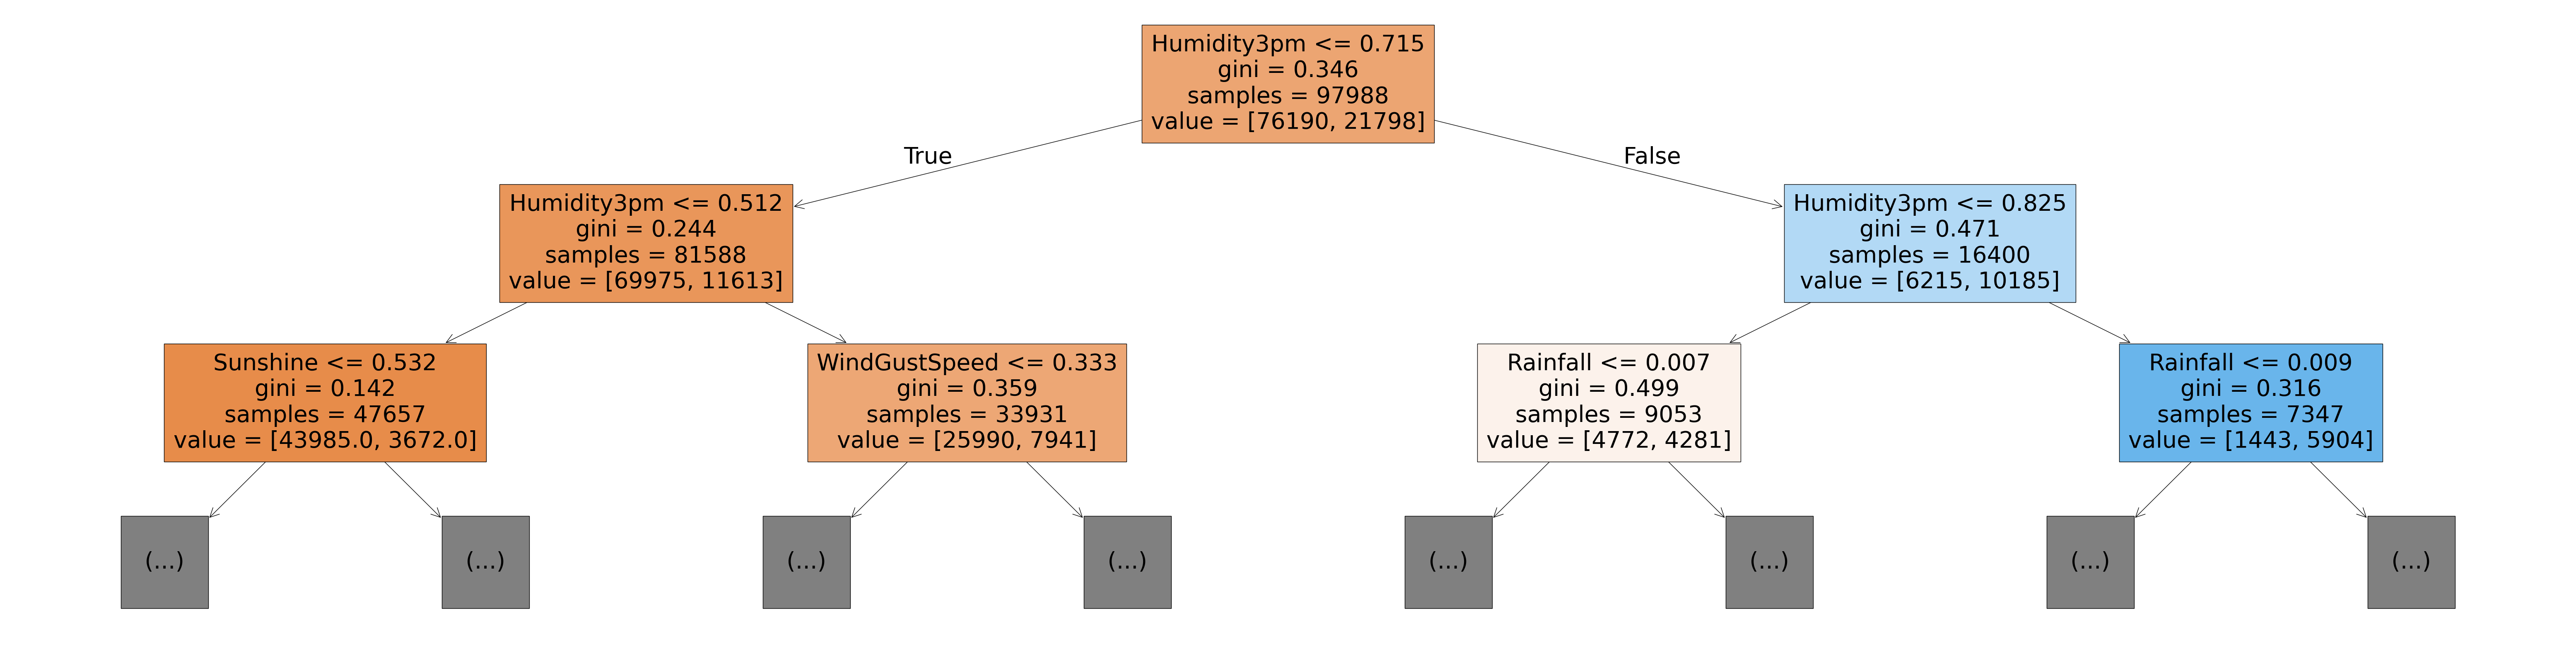

In [9]:
from sklearn.tree import plot_tree, export_text

plt.figure(figsize=(80, 20))
plot_tree(model, feature_names=train_inputs.columns, max_depth=2, filled=True)
plt.show()

In [10]:
model.tree_.max_depth

49

In [11]:
tree_text = export_text(model, feature_names=list(train_inputs.columns), max_depth=2)
print(tree_text)

|--- Humidity3pm <= 0.72
|   |--- Humidity3pm <= 0.51
|   |   |--- Sunshine <= 0.53
|   |   |   |--- truncated branch of depth 27
|   |   |--- Sunshine >  0.53
|   |   |   |--- truncated branch of depth 37
|   |--- Humidity3pm >  0.51
|   |   |--- WindGustSpeed <= 0.33
|   |   |   |--- truncated branch of depth 47
|   |   |--- WindGustSpeed >  0.33
|   |   |   |--- truncated branch of depth 31
|--- Humidity3pm >  0.72
|   |--- Humidity3pm <= 0.82
|   |   |--- Rainfall <= 0.01
|   |   |   |--- truncated branch of depth 31
|   |   |--- Rainfall >  0.01
|   |   |   |--- truncated branch of depth 31
|   |--- Humidity3pm >  0.82
|   |   |--- Rainfall <= 0.01
|   |   |   |--- truncated branch of depth 26
|   |   |--- Rainfall >  0.01
|   |   |   |--- truncated branch of depth 24



In [12]:
model.feature_importances_
importance_df = pd.DataFrame({
    'feature': train_inputs.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
importance_df

,feature,importance
9,Humidity3pm,0.279305
11,Pressure3pm,0.061308
5,WindGustSpeed,0.059544
4,Sunshine,0.046697
2,Rainfall,0.043654
...,...,...
29,Location_Darwin,0.000505
55,Location_Townsville,0.000307
57,Location_Uluru,0.000265
40,Location_Newcastle,0.000167


We try and reduce overfitting using hyperparameters

In [13]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(train_inputs, train_targets)
print(model.score(train_inputs, train_targets))
print(model.score(val_inputs, val_targets))

0.8315916234640977
0.8348060155655685


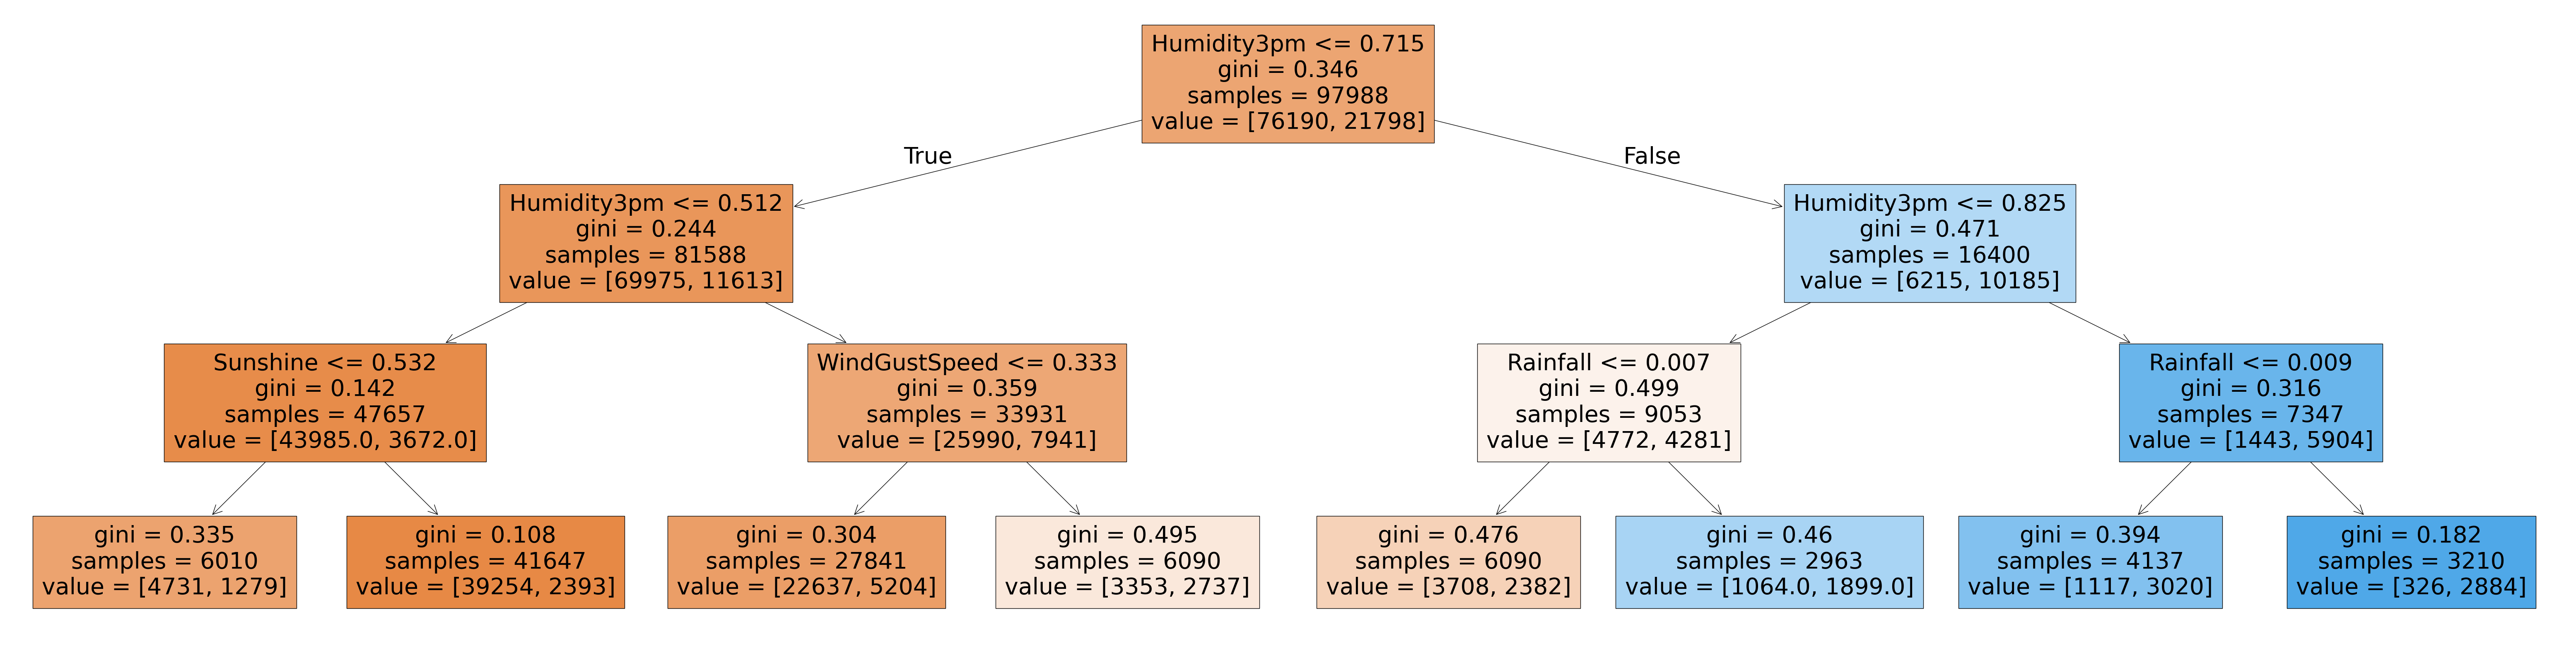

In [14]:
plt.figure(figsize=(80, 20))
plot_tree(model, feature_names=train_inputs.columns, filled=True)
plt.show()

We experiment with different depths using a helper function

In [15]:
def max_depth_error(max_depth):
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(train_inputs, train_targets)
    train_error = 1 - model.score(train_inputs, train_targets)
    val_error = 1 - model.score(val_inputs, val_targets)
    return {'Max Depth': max_depth, 'Train Error': train_error, 'Validation Error': val_error}

errors_df = pd.DataFrame([max_depth_error(d) for d in range(1, 21)])
errors_df

,Max Depth,Train Error,Validation Error
0,1,0.181941,0.176488
1,2,0.176930,0.170695
2,3,0.168408,0.165194
3,4,0.162153,0.161624
4,5,0.157244,0.158113
5,6,0.153131,0.155890
6,7,0.149059,0.154661
7,8,0.144814,0.154017
8,9,0.139374,0.154602
9,10,0.131792,0.155129


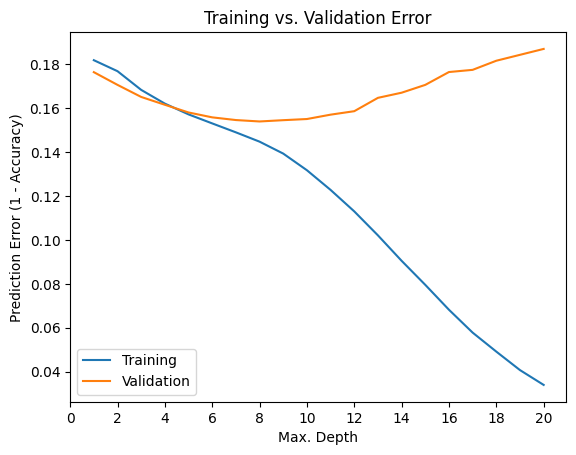

In [16]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['Train Error'])
plt.plot(errors_df['Max Depth'], errors_df['Validation Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])
plt.show()

In [17]:
model = DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)
model.fit(train_inputs, train_targets)
print(model.score(train_inputs, train_targets))
print(model.score(val_inputs, val_targets))
model.tree_.max_depth

0.852696248520227
0.8471531394464276


11

Now we try and train a random forest

In [20]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_jobs=-1, random_state=42)
model.fit(train_inputs, train_targets)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [21]:
print(model.score(train_inputs, train_targets))
print(model.score(val_inputs, val_targets))

0.9999795893374699
0.8572766106852361


In [22]:
len(model.estimators_)

100

In [23]:
importance_df = pd.DataFrame({
    'feature': train_inputs.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df

,feature,importance
9,Humidity3pm,0.132600
4,Sunshine,0.060382
11,Pressure3pm,0.053155
8,Humidity9am,0.050646
10,Pressure9am,0.048654
...,...,...
29,Location_Darwin,0.000717
19,Location_AliceSprings,0.000690
41,Location_Nhil,0.000537
32,Location_Katherine,0.000298


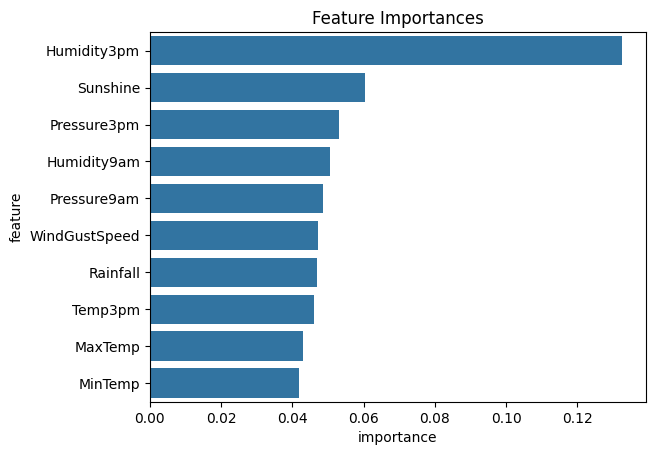

In [25]:
plt.title('Feature Importances')
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
plt.show()

Hyperparameter tuning for random forest

In [ ]:
base_model = RandomForestClassifier(n_jobs=-1, random_state=42).fit(train_inputs, train_targets)
base_train_acc = base_model.score(train_inputs, train_targets)
base_val_acc = base_model.score(val_inputs, val_targets)
base_accs = base_train_acc, base_val_acc

In [29]:
print('base model train acc:', base_train_acc)
print('base model validation acc:', base_val_acc)

base model train acc: 0.9999795893374699
base model validation acc: 0.8572766106852361


n_estimators controls the number of decision trees in the random forest. Default is 100.

In [30]:
model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=500)
model.fit(train_inputs, train_targets)
train_acc = model.score(train_inputs, train_targets)
val_acc = model.score(val_inputs, val_targets)
print('model train acc:', train_acc)
print('model validation acc:', val_acc)

model train acc: 0.9999795893374699
model validation acc: 0.8565744045877465


In [ ]:
def test_params(**params):
    model = RandomForestClassifier(random_state=42, n_jobs=-1, **params).fit(train_inputs, train_targets)
    return model.score(train_inputs, train_targets), model.score(val_inputs, val_targets)

errors_df = pd.DataFrame([test_params(max_depth=d) for d in range(1, 21)])
errors_df

,0,1
0,0.777544,0.790626
1,0.777565,0.790626
2,0.796342,0.803090
3,0.812140,0.817309
4,0.823662,0.827842
5,0.831898,0.833460
6,0.838919,0.838844
7,0.844471,0.841653
8,0.848839,0.843408
9,0.855972,0.845632


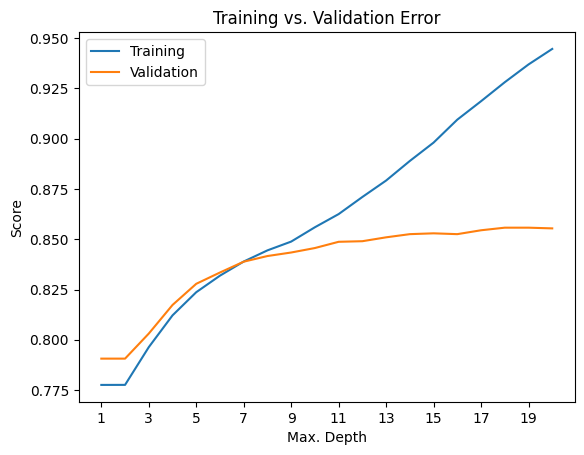

In [38]:
plt.figure()
plt.plot(range(1, 21), errors_df[0], label='Training')
plt.plot(range(1, 21), errors_df[1], label='Validation')
plt.title('Training vs. Validation Error')
plt.xticks(range(1, 21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Score')
plt.legend()
plt.show()

Trying out max_features. Default is sqrt(n) is to be chosen randomly at each split

In [40]:
test_params(max_features='log2')

(0.9999795893374699, 0.8569840248112821)

In [41]:
test_params(max_features=20)

(0.9999795893374699, 0.8579788167827257)

min_samples_split and min_samples_leaves

In [42]:
test_params(min_samples_split=5, min_samples_leaf=2)

(0.9572294566681635, 0.8579202996079349)

In [43]:
model = RandomForestClassifier(n_jobs=-1, 
                               random_state=42, 
                               n_estimators=500,
                               max_features=7,
                               max_depth=30, 
                               class_weight={'No': 1, 'Yes': 1.5})
model.fit(train_inputs, train_targets)
print(model.score(train_inputs, train_targets))
print(model.score(val_inputs, val_targets))
print(base_accs)

0.9924378495325958
0.8577447480835625
(0.9999795893374699, 0.8572766106852361)


In [44]:
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit

X_search = pd.concat([train_inputs, val_inputs], axis=0)
y_search = pd.concat([train_targets, val_targets], axis=0)


In [45]:
split_index = np.concatenate([
    np.full(len(train_inputs), -1),  # -1 means train
    np.full(len(val_inputs), 0)      # 0 means validation fold
])

predefined_split = PredefinedSplit(split_index)


We use random search CV to tune the hyperparameters

In [46]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, 40, None],
    "max_features": ["sqrt", "log2", 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "class_weight": [None, "balanced", {"No": 1, "Yes": 1.5}, {"No": 1, "Yes": 2}]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring="accuracy",
    cv=predefined_split,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

search.fit(X_search, y_search)


Fitting 1 folds for each of 30 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced', ...], 'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that c

In [ ]:
search.best_score_

np.float64(0.8592661946281234)

In [48]:
best_rf = search.best_estimator_
test_acc = best_rf.score(test_inputs, test_targets)
test_acc

0.8493193309996111

We try to ensemble this random forest model and the previous log regression model

In [49]:
import joblib

logreg_bundle = joblib.load("weather_model_bundle.joblib")
logreg_model = logreg_bundle["model"]
rf_model = best_rf

In [50]:
logreg_probs = logreg_model.predict_proba(val_inputs)[:, 1]
rf_probs = rf_model.predict_proba(val_inputs)[:, 1]

In [51]:
ensemble_probs = (logreg_probs + rf_probs) / 2
ensemble_preds = np.where(ensemble_probs >= 0.5, "Yes", "No")

In [53]:
accuracy_score(val_targets, ensemble_preds)

0.9065480718590907